# Evolution of Topography and Sediment Transport Following Valley Glaciation #
### Ries Plescher, Katie Larkin, Mirna Kassem, Keya Hopwood ###

This notebook explores how recently deglaciated valleys evolve with bedrock landsliding and fluvial transport. 

First, let's get things imported:

In [17]:
# first lets get things imported
import numpy as np
import matplotlib.pyplot as plt
from landlab import RasterModelGrid

We define our initial conditions using a) theoretical u-shaped topography, and b) a real-life valley.

## a) Theoretical topography ##

Following Harbor (1992), ice flow flows in a valley according to a parabolic profile
$$z=ax^b$$
where $$b=2$$.

To establish a realistic channel long-profile, we add a seperate exponential expression in the y-direction using coefficients from Dadson and Church (2005), resulting in the general form
$$z=ax^b+cy^d$$
where $$c=85*10^{-3}$$ and $$d=1.75$$

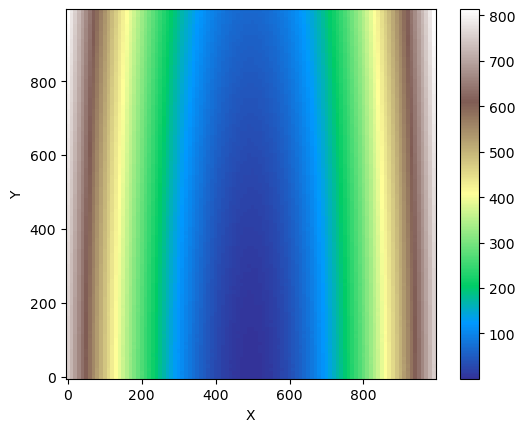

In [18]:
# set up a grid
grid_length = 1000.0 # meters
grid_width = 1000.0 # meters
grid_res = 10.0 # meters

xvals = np.linspace(-grid_width/2,grid_width/2,int(grid_width/grid_res))
yvals = np.linspace(0,grid_length,int(grid_length/grid_res))
xv, yv = np.meshgrid(xvals,yvals)

# parameters for parabolic glacial valley
a=0.003 # set so that valley ridge height is realistic
b=2
c=1e-3
d=1.6
zv = a*(xv**b) + c*(yv**d)

# add a small amount of noise to reduce artifacting
noise = np.random.rand(zv.shape[0],zv.shape[1])
sim_glac = zv + noise

# initialize a RasterGridObject
theo_grid = RasterModelGrid(sim_glac.shape, 10.0)
theo_grid.at_node['topographic__elevation'] = sim_glac
theo_grid.imshow('topographic__elevation',cmap='terrain')

## a) Real topography ##

We take this topography from somewhere in alaska idk